# 지연 위험도(정상/주의/위험) 분류 모델 — LightGBM

`ml_delayrisk_classification/models/delayrisk_model.py`와 동일한 로직을 셀 단위로 옮긴 노트북입니다.
학습 로직 자체(피처 인코딩, 클래스 불균형 보정, LightGBM multiclass 학습, 평가, 저장/로드, 실시간 추론)는 `.py` 파일과 완전히 동일하며,
탐색적으로 중간 결과(클래스 분포, 혼동 행렬 등)를 바로 확인할 수 있도록 노트북 형태로 구성했습니다.

실제로 이 노트북에서 학습을 실행하려면 `ml_delayrisk_classification/config.py`에 설정된 MongoDB(`ml_dashboard`)에
접속 가능해야 합니다.


# Feature Descriptions (피처 설명 목록)

| 피처명 (Feature Name) | 설명 (Description) |
| :--- | :--- |
| `project_key` | 프로젝트 코드 (이슈 키 접두사, 예: JELLY) |
| `issuetype_name` | 이슈 유형 (Bug/Task/Improvement 등) |
| `priority_name` | 우선순위 (Blocker/Critical/Major/Minor/Trivial) |
| `reporter` | 이슈 등록자 (빈도 인코딩) |
| `is_subtask` | 하위 작업(subtask) 여부 |
| `has_parent` | 상위 이슈(에픽 등)에 속해 있는지 여부 |
| `parent_unresolved` | 상위 이슈(에픽)가 아직 미해결 상태인지 여부 |
| `num_subtasks` | 하위 작업 개수 |
| `num_unresolved_subtasks` | 하위 작업 중 미해결 개수 |
| `num_components` | 소속 컴포넌트(모듈) 개수 |
| `num_fixversions` | 목표 릴리즈 버전 개수 |
| `has_released_fixversion` | 목표 릴리즈 버전 중 이미 배포된 것이 있는지 여부 |
| `num_versions` | 영향받는 버전 개수 |
| `has_original_estimate` | 최초 예상 소요시간(estimate)이 설정되어 있는지 여부 |
| `original_estimate_seconds` | 최초 예상 소요시간(초 단위) |
| `num_issuelinks_total` | 다른 이슈와의 연관관계 총 개수 |
| `num_blocked_by_links` | '~에 의해 막힘' 관계 개수 |
| `num_unresolved_blockers` | 블로커 이슈 중 아직 해결되지 않은 것의 개수 |
| `created_day_of_week` | 생성 요일 (0=월요일 ~ 6=일요일) |
| `created_hour` | 생성 시각 (0~23시) |
| `summary_length` | 이슈 제목 길이 (문자 수, 복잡도 근사치) |
| `status_at_cutoff` | cutoff 시점의 상태 (Open/In Progress/Blocked 등) |
| `assignee_at_cutoff` | cutoff 시점의 담당자 (빈도 인코딩) |
| `num_events_before_cutoff` | cutoff 이전 변경 이력(이벤트) 총 개수 |
| `num_status_changes` | 상태 변경 횟수 |
| `num_assignee_changes` | 담당자 변경(재배정) 횟수 |
| `num_reopens` | 상태가 Open/Reopened로 되돌아간 횟수 |
| `hours_in_current_status` | 마지막 상태 변경 이후 ~ cutoff까지 경과한 시간 |
| `blocked_hours_before_cutoff` | 블로커 상태에 머문 누적 시간 |
| `num_comments_before_cutoff` | cutoff 이전 댓글 수 |
| `num_unique_commenters` | 댓글을 남긴 고유 인원 수 |
| `hours_since_last_comment` | 마지막 댓글로부터 ~ cutoff까지 경과 시간 |
| `num_worklog_entries` | 작업 기록(worklog) 건수 (봇 계정 제외) |
| `num_unique_workers` | 실제 작업한 고유 인원 수 |
| `time_spent_seconds_before_cutoff` | cutoff까지 누적 투입 시간 (초, 봇 제외) |
| `progress_ratio_at_cutoff` | 진행률 (누적 투입시간 ÷ 최초 예상시간) |
| `elapsed_hours_at_cutoff` | 이슈 생성 후 ~ cutoff까지 경과 시간 (절대값, 시간 단위) |
| `activity_count_recent_window` | 최근 N일간 활동(댓글+상태변경+작업기록) 합계 |
| `is_self_assigned` | 보고자와 담당자가 동일 인물인지 여부 |
| `snapshot_offset_days` | 스냅샷 시점 (이슈 생성 후 며칠째인지) |

## 1. 환경 설정 — 노트북 위치와 무관하게 backend_fastapi를 찾아 `sys.path`에 추가

In [14]:
import sys
from pathlib import Path


def _find_backend_fastapi_root() -> Path:
    # VS Code Jupyter 확장은 현재 열린 노트북의 절대경로를 __vsc_ipynb_file__ 전역변수로 제공한다.
    # 이게 없는 환경(JupyterLab 등)에서는 커널의 현재 작업 디렉터리(cwd)로 대체한다.
    notebook_path = globals().get("__vsc_ipynb_file__")
    search_start = Path(notebook_path).resolve().parent if notebook_path else Path.cwd()

    # 노트북이 ml_delayrisk_classification/ 바로 아래에 있든 models/ 등 하위 폴더로
    # 옮겨지든 상관없이 상위 폴더를 훑어 backend_fastapi(=ml_delayrisk_classification의
    # 부모)를 찾는다. cwd에 의존하는 방식(Path.cwd().parent)은 노트북 프론트엔드마다
    # 커널 작업 디렉터리가 달라 깨지기 쉬워 사용하지 않는다.
    for candidate in [search_start, *search_start.parents]:
        if (candidate / "ml_delayrisk_classification").is_dir():
            return candidate
        if (candidate / "backend_fastapi" / "ml_delayrisk_classification").is_dir():
            return candidate / "backend_fastapi"

    raise RuntimeError(
        f"'{search_start}' 및 상위 폴더에서 ml_delayrisk_classification 패키지를 찾지 못했습니다.\n"
        "노트북이 backend_fastapi 프로젝트 안에 있는지 확인하거나, 아래처럼 경로를 직접 추가하세요:\n"
        '    sys.path.insert(0, r"D:\\...\\backend_fastapi")'
    )


BACKEND_FASTAPI_ROOT = _find_backend_fastapi_root()
if str(BACKEND_FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_FASTAPI_ROOT))

print("BACKEND_FASTAPI_ROOT =", BACKEND_FASTAPI_ROOT)
print("sys.path[0] =", sys.path[0])


BACKEND_FASTAPI_ROOT = D:\AIproject\project\Team\work-flow\App\backend_fastapi
sys.path[0] = D:\AIproject\project\Team\work-flow\App\backend_fastapi


## 2. Imports

In [15]:
from __future__ import annotations

import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Optional

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# Windows 기본 한글 글꼴로 설정 (미설정 시 혼동행렬의 한글 라벨이 네모(tofu)로 깨짐)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 위 폰트 사용 시 마이너스 기호 깨짐 방지
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold

from ml_delayrisk_classification.models.feature_engineering import RISK_CLASS_NAMES
from ml_delayrisk_classification.config import get_settings

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)


## 3. 상수 정의

- `CATEGORICAL_COLUMNS`: LightGBM 네이티브 범주형 처리 대상 (저카디널리티).
- `FREQUENCY_ENCODED_COLUMNS`: 담당자/보고자처럼 카디널리티가 높은 컬럼은 빈도 인코딩으로 처리.
- `NON_FEATURE_COLUMNS`: 학습에 쓰지 않는 부기(bookkeeping) 컬럼. `proxy_deadline_hours`는
  issuetype/priority로 이미 결정되는 중복 정보라 피처에서 제외합니다.


In [ ]:
NUM_CLASSES = 3
CATEGORICAL_COLUMNS = ["issuetype_name", "priority_name", "project_key", "status_at_cutoff"]
FREQUENCY_ENCODED_COLUMNS = ["reporter", "assignee_at_cutoff"]

# <데이터 누수 방지>
# (해결)
# LEAKY_FEATURE_COLUMNS를 NON_FEATURE_COLUMNS에 재합류 (cell 6) 
# — elapsed_ratio_at_cutoff, blocked_ratio_at_cutoff, imbalance_index_at_cutoff, hours_until_deadline_at_cutoff 
# 4개를 다시 피처에서 제외.

# (문제 원인)
# elapsed_ratio_at_cutoff / blocked_ratio_at_cutoff / imbalance_index_at_cutoff는
# risk_class 라벨을 계산하는 classify_risk()의 입력값 그 자체이고,
# hours_until_deadline_at_cutoff는 proxy_deadline_hours - elapsed_hours_at_cutoff로
# 역산 가능해 사실상 동일한 정보다. 피처로 남겨두면 모델이 패턴을 학습하는 대신
# 라벨링 규칙식을 그대로 베껴버린다(타겟 누수).
LEAKY_FEATURE_COLUMNS = [
    "elapsed_ratio_at_cutoff",
    "blocked_ratio_at_cutoff",
    "imbalance_index_at_cutoff",
    "hours_until_deadline_at_cutoff",
]
NON_FEATURE_COLUMNS = [
    "issue_key",
    "created",
    "risk_class",
    "proxy_deadline_hours",
] + LEAKY_FEATURE_COLUMNS

# 후보 피처들의 의미 설명 (선정 결과를 사람이 읽을 수 있게 출력할 때 사용).
# feature_engineering.py의 build_static_features/build_dynamic_features가 만드는
# 필드와 1:1로 대응한다.
FEATURE_DESCRIPTIONS: dict[str, str] = {
    "project_key": "프로젝트 코드 (이슈 키 접두사, 예: JELLY)",
    "issuetype_name": "이슈 유형 (Bug/Task/Improvement 등)",
    "priority_name": "우선순위 (Blocker/Critical/Major/Minor/Trivial)",
    "reporter": "이슈 등록자 (빈도 인코딩)",
    "is_subtask": "하위 작업(subtask) 여부",
    "has_parent": "상위 이슈(에픽 등)에 속해 있는지 여부",
    "parent_unresolved": "상위 이슈(에픽)가 아직 미해결 상태인지 여부",
    "num_subtasks": "하위 작업 개수",
    "num_unresolved_subtasks": "하위 작업 중 미해결 개수",
    "num_components": "소속 컴포넌트(모듈) 개수",
    "num_fixversions": "목표 릴리즈 버전 개수",
    "has_released_fixversion": "목표 릴리즈 버전 중 이미 배포된 것이 있는지 여부",
    "num_versions": "영향받는 버전 개수",
    "has_original_estimate": "최초 예상 소요시간(estimate)이 설정되어 있는지 여부",
    "original_estimate_seconds": "최초 예상 소요시간(초 단위)",
    "num_issuelinks_total": "다른 이슈와의 연관관계 총 개수",
    "num_blocked_by_links": "'~에 의해 막힘' 관계 개수",
    "num_unresolved_blockers": "블로커 이슈 중 아직 해결되지 않은 것의 개수",
    "created_day_of_week": "생성 요일 (0=월요일 ~ 6=일요일)",
    "created_hour": "생성 시각 (0~23시)",
    "summary_length": "이슈 제목 길이 (문자 수, 복잡도 근사치)",
    "status_at_cutoff": "cutoff 시점의 상태 (Open/In Progress/Blocked 등)",
    "assignee_at_cutoff": "cutoff 시점의 담당자 (빈도 인코딩)",
    "num_events_before_cutoff": "cutoff 이전 변경 이력(이벤트) 총 개수",
    "num_status_changes": "상태 변경 횟수",
    "num_assignee_changes": "담당자 변경(재배정) 횟수",
    "num_reopens": "상태가 Open/Reopened로 되돌아간 횟수",
    "hours_in_current_status": "마지막 상태 변경 이후 ~ cutoff까지 경과한 시간",
    "blocked_hours_before_cutoff": "블로커 상태에 머문 누적 시간",
    "num_comments_before_cutoff": "cutoff 이전 댓글 수",
    "num_unique_commenters": "댓글을 남긴 고유 인원 수",
    "hours_since_last_comment": "마지막 댓글로부터 ~ cutoff까지 경과 시간",
    "num_worklog_entries": "작업 기록(worklog) 건수 (봇 계정 제외)",
    "num_unique_workers": "실제 작업한 고유 인원 수",
    "time_spent_seconds_before_cutoff": "cutoff까지 누적 투입 시간 (초, 봇 제외)",
    "progress_ratio_at_cutoff": "진행률 (누적 투입시간 ÷ 최초 예상시간)",
    "elapsed_hours_at_cutoff": "이슈 생성 후 ~ cutoff까지 경과 시간 (절대값, 시간 단위)",
    "activity_count_recent_window": "최근 N일간 활동(댓글+상태변경+작업기록) 합계",
    "is_self_assigned": "보고자와 담당자가 동일 인물인지 여부",
    "snapshot_offset_days": "스냅샷 시점 (이슈 생성 후 며칠째인지)",
}


## 4. 모델 아티팩트 정의

학습된 booster와 함께, 추론 시 동일하게 재현해야 하는 인코딩 맵·Proxy Deadline 조회 테이블을 함께 묶어 저장합니다.

In [17]:
@dataclass
class ModelArtifact:
    booster: lgb.Booster
    feature_names: list[str]
    categorical_columns: list[str]
    frequency_maps: dict[str, dict[str, int]]
    proxy_deadline_map: dict[tuple[str, str], float]
    global_median_duration_hours: float


## 5. 전처리 헬퍼 함수

In [18]:
def _feature_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c not in NON_FEATURE_COLUMNS]


def _apply_frequency_encoding(df: pd.DataFrame, freq_maps: dict[str, dict[str, int]]) -> pd.DataFrame:
    df = df.copy()
    for col in FREQUENCY_ENCODED_COLUMNS:
        if col in df.columns:
            df[col] = df[col].map(freq_maps.get(col, {})).fillna(0).astype(int)
    return df


def _apply_categorical_dtype(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in CATEGORICAL_COLUMNS:
        if col in df.columns:
            df[col] = df[col].astype("category")
    return df


def _sample_weights(labels: pd.Series) -> np.ndarray:
    """클래스 불균형('위험' 표본이 '정상'보다 현저히 적음) 보정용 역빈도 가중치."""
    counts = labels.value_counts()
    total = len(labels)
    weight_map = {cls: total / (len(counts) * count) for cls, count in counts.items()}
    return labels.map(weight_map).to_numpy()


## 5-1. 피처 선정 — 중요도 분석 (학습/검증 분할 이전)

피처가 너무 많고 복잡하다는 판단에 따라, 실제 train/valid 분할 전에 **전체 데이터**로 LightGBM 프로브 모델의 피처 중요도(gain)를 계산해 중요한 피처만 골라낸다. 이후 `train_and_save`의 실제 학습은 이 선정된 피처만 사용한다.


In [19]:
def select_important_features(
    df: pd.DataFrame,
    importance_threshold: float = 0.01,
) -> tuple[list[str], pd.DataFrame]:
    """학습/검증 분할 이전에 전체 데이터로 피처 중요도를 분석해 중요한 피처만 선정한다.
    이후 실제 학습(train_and_save)은 이 피처만 사용한다.

    - 중요도: 전체 데이터로 LightGBM 프로브 모델(평가/검증용이 아니라 순위 산정 전용)을
      한 번 학습해 gain 기준 피처 중요도를 계산하고 100% 기준으로 정규화한다.
    - 선정 기준: 정규화 중요도(gain)가 importance_threshold 이상인 피처만 선택한다.
    """
    candidate_features = _feature_columns(df)

    freq_maps = {
        col: df[col].value_counts().to_dict()
        for col in FREQUENCY_ENCODED_COLUMNS
        if col in df.columns
    }
    encoded_df = _apply_categorical_dtype(_apply_frequency_encoding(df, freq_maps))
    categorical_columns = [c for c in CATEGORICAL_COLUMNS if c in candidate_features]

    probe_set = lgb.Dataset(
        encoded_df[candidate_features],
        label=encoded_df["risk_class"],
        weight=_sample_weights(encoded_df["risk_class"]),
        categorical_feature=categorical_columns,
    )
    probe_booster = lgb.train(
        {
            "objective": "multiclass",
            "num_class": NUM_CLASSES,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "verbose": -1,
        },
        probe_set,
        num_boost_round=200,
    )

    gain = probe_booster.feature_importance(importance_type="gain")
    split_count = probe_booster.feature_importance(importance_type="split")
    gain_pct = gain / gain.sum() * 100 if gain.sum() > 0 else gain

    report = pd.DataFrame(
        {
            "feature": candidate_features,
            "importance_gain_pct": gain_pct,
            "importance_split": split_count,
        }
    )
    report = report.sort_values("importance_gain_pct", ascending=False).reset_index(drop=True)

    selected_mask = report["importance_gain_pct"] / 100 >= importance_threshold
    selected_features = report.loc[selected_mask, "feature"].tolist()

    logger.info(
        "피처 선정: 후보 %d개 중 %d개 선정 (기준: 중요도 %.1f%% 이상, gain 기준 단독 선정)",
        len(candidate_features),
        len(selected_features),
        importance_threshold * 100,
    )
    logger.info("\n%s", report.to_string(index=False))

    # 선정된 피처가 실제로 무엇을 의미하는지 사람이 바로 확인할 수 있도록 설명을 함께 출력.
    print(f"\n선정된 피처 {len(selected_features)}개 설명 (중요도 내림차순):")
    selected_report = report[report["feature"].isin(selected_features)]
    for _, row in selected_report.iterrows():
        description = FEATURE_DESCRIPTIONS.get(row["feature"], "(설명 미등록)")
        print(f"  - {row['feature']} (중요도 {row['importance_gain_pct']:.1f}%): {description}")

    plot_df = report[report["feature"].isin(selected_features)].sort_values("importance_gain_pct")
    fig, ax = plt.subplots(figsize=(7, max(4, len(selected_features) * 0.35)))
    sns.barplot(data=plot_df, x="importance_gain_pct", y="feature", color="#4C72B0", ax=ax)
    ax.set_xlabel("중요도 (Gain, %)")
    ax.set_ylabel("")
    ax.set_title("선정된 피처 중요도")
    fig.tight_layout()
    visualization_dir = Path(get_settings().visualization_dir)
    visualization_dir.mkdir(parents=True, exist_ok=True)
    feature_importance_path = visualization_dir / "feature_importance.png"
    fig.savefig(feature_importance_path)
    logger.info("피처 중요도 이미지 저장: %s", feature_importance_path)
    plt.show()
    plt.close(fig)

    return selected_features, report


## 6. 학습 함수 (`train_and_save`)

- 시간(`created`) 기준으로 정렬 후 마지막 `test_size` 구간을 검증셋으로 분리 (미래 누수 방지를 위한 time-based split).
- `objective="multiclass"`, `num_class=3`으로 정상(0)/주의(1)/위험(2) 3단계를 한 번에 분류.
- 클래스 불균형 보정을 위해 역빈도 샘플 가중치 적용.
- F1-Macro, classification report, 혼동 행렬로 클래스별 성능을 확인 (단순 accuracy는 '위험' 소수 클래스 성능을 가려서 부적합).


In [20]:
def train_and_save(
    df: pd.DataFrame,
    proxy_deadline_map: dict[tuple[str, str], float],
    global_median_duration_hours: float,
    test_size: float = 0.2,
    importance_threshold: float = 0.01,
) -> ModelArtifact:
    df = df.sort_values("created").reset_index(drop=True)

    # <피처 선정 — 학습/검증 분할 이전에 전체 데이터로 수행>
    # (해결) select_important_features()로 중요도(gain) 분석 후 피처 축소(gain 기준 단독 선정).
    # (이유) 피처가 너무 많고 복잡하다는 판단에 따라, 분할 이전 단계에서 중요한 피처만
    # 추려 이후 학습·평가·추론 전체에서 이 피처만 사용한다.
    selected_features, feature_selection_report = select_important_features(
        df, importance_threshold=importance_threshold
    )

    # <학습/테스트 데이터 - 층화추출 적용>
    # (해결)
    # StratifiedGroupKFold로 분할 재적용 (cell 12, train_and_save) 
    # — issue_key 단위로 그룹을 통째로 배정하고, 그룹 대표 라벨(이슈가 도달한 최고 위험도)로 층화해 
    # 희귀 클래스도 train/valid 양쪽에 고르게 배분.
    # (문제 원인)
    # 같은 issue_key의 여러 스냅샷이 train/valid 양쪽에 걸쳐 들어가면 그룹 누수가 생기므로,
    # 이슈 단위(issue_key)로 그룹을 통째로 한쪽에만 배정한다. 그룹 대표 라벨은 해당 이슈가
    # 도달한 최고 위험도(risk_class 최댓값)로 잡아, StratifiedGroupKFold가 희귀 클래스('주의')도
    # train/valid 양쪽에 고르게 배분하도록 한다.
    group_labels = df.groupby("issue_key")["risk_class"].max()
    issue_keys = group_labels.index.to_numpy()
    n_splits = max(2, round(1 / test_size))
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_issue_idx, valid_issue_idx = next(
        splitter.split(
            np.zeros(len(issue_keys)), group_labels.to_numpy(), groups=issue_keys
        )
    )
    train_issues = set(issue_keys[train_issue_idx])
    valid_issues = set(issue_keys[valid_issue_idx])

    train_df = df[df["issue_key"].isin(train_issues)].copy()
    test_df = df[df["issue_key"].isin(valid_issues)].copy()

    all_classes = set(df["risk_class"].unique())
    missing_in_train = all_classes - set(train_df["risk_class"].unique())
    missing_in_valid = all_classes - set(test_df["risk_class"].unique())
    if missing_in_train:
        logger.warning("train 세트에 없는 클래스: %s", missing_in_train)
    if missing_in_valid:
        logger.warning("valid 세트에 없는 클래스: %s", missing_in_valid)

    frequency_maps = {
        col: train_df[col].value_counts().to_dict()
        for col in FREQUENCY_ENCODED_COLUMNS
        if col in train_df.columns
    }

    train_df = _apply_categorical_dtype(_apply_frequency_encoding(train_df, frequency_maps))
    test_df = _apply_categorical_dtype(_apply_frequency_encoding(test_df, frequency_maps))

    # 위에서 분할 이전 전체 데이터로 선정한 피처만 사용(피처 개수 축소).
    feature_names = [c for c in selected_features if c in train_df.columns]
    categorical_columns = [c for c in CATEGORICAL_COLUMNS if c in feature_names]

    train_weights = _sample_weights(train_df["risk_class"])

    train_set = lgb.Dataset(
        train_df[feature_names],
        label=train_df["risk_class"],
        weight=train_weights,
        categorical_feature=categorical_columns,
    )
    valid_set = lgb.Dataset(
        test_df[feature_names],
        label=test_df["risk_class"],
        categorical_feature=categorical_columns,
        reference=train_set,
    )

    params = {
        "objective": "multiclass",
        "num_class": NUM_CLASSES,
        "metric": ["multi_logloss", "multi_error"],
        "learning_rate": 0.05,
        "num_leaves": 31,
        "verbose": -1,
    }

    booster = lgb.train(
        params,
        train_set,
        num_boost_round=500,
        valid_sets=[train_set, valid_set],
        valid_names=["train", "valid"],
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)],
    )

    probabilities = booster.predict(test_df[feature_names], num_iteration=booster.best_iteration)
    predicted_labels = np.argmax(probabilities, axis=1)

    class_labels = list(range(NUM_CLASSES))
    target_names = [RISK_CLASS_NAMES[i] for i in class_labels]
    logger.info(
        "검증 F1-Macro: %.4f",
        f1_score(test_df["risk_class"], predicted_labels, labels=class_labels, average="macro"),
    )
    logger.info(
        "\n%s",
        classification_report(
            test_df["risk_class"],
            predicted_labels,
            labels=class_labels,
            target_names=target_names,
            zero_division=0,
        ),
    )
    cm = confusion_matrix(test_df["risk_class"], predicted_labels, labels=class_labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        cbar=False,
        ax=ax,
    )
    ax.set_xlabel("예측")
    ax.set_ylabel("실제")
    ax.set_title("혼동 행렬 (행=실제 / 열=예측)")
    fig.tight_layout()
    visualization_dir = Path(get_settings().visualization_dir)
    visualization_dir.mkdir(parents=True, exist_ok=True)
    confusion_matrix_path = visualization_dir / "confusion_matrix.png"
    fig.savefig(confusion_matrix_path)
    logger.info("혼동 행렬 이미지 저장: %s", confusion_matrix_path)
    plt.show()
    plt.close(fig)

    artifact = ModelArtifact(
        booster=booster,
        feature_names=feature_names,
        categorical_columns=categorical_columns,
        frequency_maps=frequency_maps,
        proxy_deadline_map=proxy_deadline_map,
        global_median_duration_hours=global_median_duration_hours,
    )
    _save_artifact(artifact)
    return artifact


## 7. 모델 저장/로드

In [21]:
def _model_path() -> Path:
    settings = get_settings()
    path = Path(settings.model_dir)
    path.mkdir(parents=True, exist_ok=True)
    return path / settings.model_filename


def _save_artifact(artifact: ModelArtifact) -> None:
    path = _model_path()
    joblib.dump(artifact, path)
    logger.info("모델 저장 완료: %s", path)


_artifact_cache: Optional[ModelArtifact] = None


def load_artifact() -> ModelArtifact:
    global _artifact_cache
    if _artifact_cache is None:
        path = _model_path()
        if not path.exists():
            raise FileNotFoundError(
                f"학습된 모델이 없습니다: {path}. "
                "먼저 아래 '학습 실행' 셀을 실행하세요."
            )
        _artifact_cache = joblib.load(path)
    return _artifact_cache


## 8. 실시간 추론용 함수

In [22]:
def proxy_deadline_for(issuetype_name: str, priority_name: str) -> float:
    artifact = load_artifact()
    return artifact.proxy_deadline_map.get(
        (issuetype_name, priority_name), artifact.global_median_duration_hours
    )


def predict_class_probabilities(feature_row: dict[str, Any]) -> list[float]:
    """클래스 색인(0=정상,1=주의,2=위험) 순서의 확률 리스트를 반환."""
    artifact = load_artifact()
    row_df = pd.DataFrame([feature_row])

    for col in FREQUENCY_ENCODED_COLUMNS:
        if col in row_df.columns:
            row_df[col] = row_df[col].map(artifact.frequency_maps.get(col, {})).fillna(0).astype(int)

    for col in artifact.feature_names:
        if col not in row_df.columns:
            row_df[col] = None
    row_df = row_df[artifact.feature_names]

    for col in artifact.feature_names:
        if col in artifact.categorical_columns:
            row_df[col] = row_df[col].astype("category")
        else:
            # 단일 행 DataFrame에서 None(예: 예상시간 없는 이슈의 progress_ratio)은
            # object dtype이 되어 LightGBM predict가 거부한다 -> 명시적으로 float로 강제.
            row_df[col] = pd.to_numeric(row_df[col], errors="coerce")

    probabilities = artifact.booster.predict(row_df, num_iteration=artifact.booster.best_iteration)[0]
    return [float(p) for p in probabilities]


## 9. 학습 실행

MongoDB(`ml_dashboard`)에서 실제 학습 데이터를 구성하고 위에서 정의한 `train_and_save`를 호출합니다.
`dataset_builder.build_training_dataframe`은 `ml_delayrisk_classification/models/dataset_builder.py`에
정의된, 이 노트북과 동일한 파이프라인이 사용하는 함수입니다.

`limit` 파라미터로 이슈 수를 제한하면 빠르게 파일럿 실행을 해볼 수 있습니다 (전체 데이터는 약 77만 건 규모라 시간이
오래 걸릴 수 있습니다). 운영에서는 노트북 대신 `python -m ml_delayrisk_classification.train`을 사용하세요.


In [23]:
"""
[target]업무 지연 위험도 3단계:
    Class 0 (정상): 마감일(Proxy Deadline) 이내에서 순항 중.
    Class 1 (주의): 마감일 이내지만 진행률이 저조하거나 블로커 상태에 짧게 머묾.
    Class 2 (위험): 마감일을 초과했거나, 블로커 상태에 장기간 머물러 활동이 정지(Silent).
"""
from ml_delayrisk_classification.models.dataset_builder import build_training_dataframe

# <학습 데이터 갯수 증가>
# (해결) 파일럿 limit을 300 → 1500으로 재확대
# (이유) 희귀 클래스('주의', class 1)를 학습에 충분히 사용함

# 파일럿 실행 예시 (전체 데이터로 학습하려면 limit=None)
df, proxy_deadline_map, global_median = build_training_dataframe(limit=1500)
df.shape

2026-07-16 15:24:09,750 [INFO] MongoDB 인덱스 확인/생성 완료 (events.issue, comments.issue, worklogs.issue/issueId)
2026-07-16 15:24:09,781 [INFO] Proxy Deadline 계산 완료: 그룹 30개, 전역 중앙값 521.9시간 (표본 1417건)
2026-07-16 15:24:12,474 [INFO] 완료 이슈 1500건에서 스냅샷 4633행 생성
2026-07-16 15:24:12,476 [INFO] 클래스 분포:
risk_class
0    4013
1      37
2     583
Name: count, dtype: int64


(4633, 48)

In [24]:
df["risk_class"].value_counts().sort_index()


risk_class
0    4013
1      37
2     583
Name: count, dtype: int64

2026-07-16 15:24:13,325 [INFO] 피처 선정: 후보 40개 중 6개 선정 (기준: 중요도 1.0% 이상, gain 기준 단독 선정)
2026-07-16 15:24:13,330 [INFO] 
                         feature  importance_gain_pct  importance_split
           has_original_estimate            39.039808               551
         elapsed_hours_at_cutoff            23.269456              1125
         hours_in_current_status            20.178215              1093
                   priority_name             4.792459               458
                  issuetype_name             4.385955               491
       original_estimate_seconds             3.917174               556
                  summary_length             0.771530              2584
                        reporter             0.761467              2088
        hours_since_last_comment             0.593440              1415
                    created_hour             0.510721              1954
              assignee_at_cutoff             0.446864              1415
             creat


선정된 피처 6개 설명 (중요도 내림차순):
  - has_original_estimate (중요도 39.0%): 최초 예상 소요시간(estimate)이 설정되어 있는지 여부
  - elapsed_hours_at_cutoff (중요도 23.3%): 이슈 생성 후 cutoff까지 경과 시간 (절대값, 시간 단위)
  - hours_in_current_status (중요도 20.2%): 마지막 상태 변경 이후 cutoff까지 경과한 시간
  - priority_name (중요도 4.8%): 우선순위 (Blocker/Critical/Major/Minor/Trivial)
  - issuetype_name (중요도 4.4%): 이슈 유형 (Bug/Task/Improvement 등)
  - original_estimate_seconds (중요도 3.9%): 최초 예상 소요시간(초 단위)


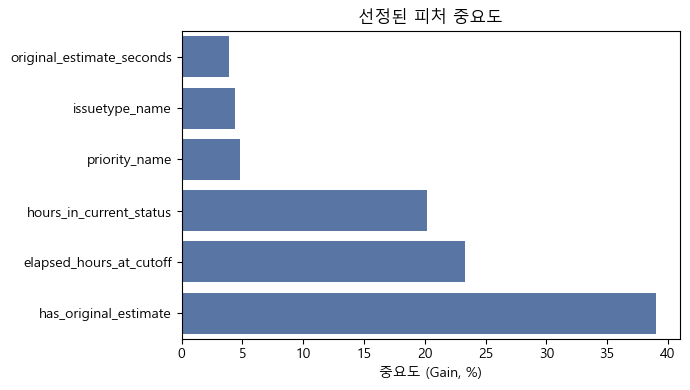

Training until validation scores don't improve for 30 rounds
[50]	train's multi_logloss: 0.0840021	train's multi_error: 0.0162875	valid's multi_logloss: 0.104227	valid's multi_error: 0.0328587


2026-07-16 15:24:14,327 [INFO] 검증 F1-Macro: 0.9249
2026-07-16 15:24:14,344 [INFO] 
              precision    recall  f1-score   support

          정상       1.00      0.99      1.00       792
          주의       0.73      0.89      0.80         9
          위험       0.97      0.98      0.98       112

    accuracy                           0.99       913
   macro avg       0.90      0.96      0.92       913
weighted avg       0.99      0.99      0.99       913

2026-07-16 15:24:14,480 [INFO] 혼동 행렬 이미지 저장: D:\AIproject\project\Team\work-flow\document_유소은\view\confusion_matrix.png


Early stopping, best iteration is:
[67]	train's multi_logloss: 0.0463274	train's multi_error: 0.00583199	valid's multi_logloss: 0.0590752	valid's multi_error: 0.00766703


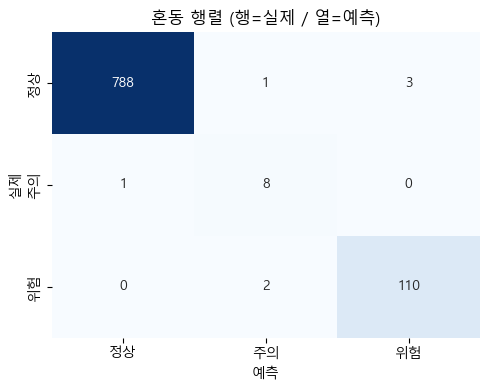

2026-07-16 15:24:14,562 [INFO] 모델 저장 완료: D:\AIproject\project\Team\work-flow\App\backend_fastapi\ml_delayrisk_classification\models\delayrisk_model.pkl


['has_original_estimate',
 'elapsed_hours_at_cutoff',
 'hours_in_current_status',
 'priority_name',
 'issuetype_name',
 'original_estimate_seconds']

In [25]:
artifact = train_and_save(df, proxy_deadline_map, global_median, test_size=0.2)
artifact.feature_names


## 10. 저장된 모델로 추론 테스트

In [26]:
# 이 노트북 안에서는 load_artifact()가 이 노트북 자체의 전역변수 _artifact_cache를 참조하므로
# (위 6~8번 셀에서 함수를 그대로 재정의했기 때문), 방금 학습한 artifact를 바로 캐시에 넣어
# 재학습 없이 재사용할 수 있습니다.
_artifact_cache = artifact

# 테스트용 데이터
sample_row = df.drop(columns=["risk_class", "created", "issue_key"]).iloc[0].to_dict()
print(display(sample_row))

# '지연 위험도 예측' 테스트 실행
probabilities = predict_class_probabilities(sample_row)
dict(zip(["정상", "주의", "위험"], probabilities))

{'project_key': 'JELLY',
 'issuetype_name': 'Bug',
 'priority_name': 'Major',
 'reporter': 'jason',
 'is_subtask': False,
 'has_parent': False,
 'parent_unresolved': False,
 'num_subtasks': 0,
 'num_unresolved_subtasks': 0,
 'num_components': 1,
 'num_fixversions': 0,
 'has_released_fixversion': False,
 'num_versions': 0,
 'has_original_estimate': False,
 'original_estimate_seconds': 0,
 'num_issuelinks_total': 0,
 'num_blocked_by_links': 0,
 'num_unresolved_blockers': 0,
 'created_day_of_week': 1,
 'created_hour': 19,
 'summary_length': 54,
 'status_at_cutoff': 'Open',
 'assignee_at_cutoff': 'jstrachan',
 'num_events_before_cutoff': 0,
 'num_status_changes': 0,
 'num_assignee_changes': 0,
 'num_reopens': 0,
 'hours_in_current_status': 24.0,
 'blocked_hours_before_cutoff': 0,
 'blocked_ratio_at_cutoff': 0.0,
 'num_comments_before_cutoff': 1,
 'num_unique_commenters': 1,
 'hours_since_last_comment': 23.93638888888889,
 'num_worklog_entries': 0,
 'num_unique_workers': 0,
 'time_spent_sec

None


{'정상': 0.990635321630794,
 '주의': 0.0046823391170650415,
 '위험': 0.0046823392521410856}